In [1]:
# Set working directory to the parent folder of this script
import os
import sys
# Set working directory to the parent folder of the current working directory
script_dir = os.getcwd()
parent_dir = os.path.dirname(script_dir)
os.chdir(parent_dir)
sys.path.insert(0, parent_dir)

from src.modules import *
from src.classification import *
import os

def make_linearly_separable(n_samples= 100, n_features=2, n_redundant=0, n_informative=2, random_state=1, n_clusters_per_class=1, noise = 0, randomstate = 10):
    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_redundant=n_redundant,
        n_informative=n_informative,
        n_clusters_per_class=n_clusters_per_class,
        random_state=random_state
    )
    rng = np.random.RandomState(randomstate)
    X += noise * rng.standard_normal(size=X.shape)
    return (X, y)

def make_xor(n_samples = 100, randomstate=1):
    rng = np.random.RandomState(randomstate)
    X_xor = rng.randn(n_samples, 2)
    X_xor += 2 * rng.standard_normal(size=X_xor.shape)
    y_xor = np.logical_xor(X_xor[:, 0] > 0, X_xor[:, 1] > 0).astype(int)  
    return (X_xor, y_xor)  

# 01 Classification

## Benchmark data

In [2]:

names = [
    "Nearest Neighbors",
    "Linear SVM",
    "RBF SVM",
    "Gaussian Process",
    "Decision Tree",
    "Random Forest",
    "Neural Net",
    "AdaBoost",
    "Naive Bayes",
    "QDA",
    "KLRClassifier"
]


classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025, random_state=42),
    SVC(gamma=2, C=1, random_state=42),
    GaussianProcessClassifier(1.0 * RBF(1.0), random_state=42),
    DecisionTreeClassifier(max_depth=5, random_state=42),
    RandomForestClassifier(
        max_depth=5, n_estimators=10, max_features=1, random_state=42
    ),
    MLPClassifier(alpha=1, max_iter=1000, random_state=42),
    AdaBoostClassifier(random_state=42),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
    KLRClassifier()
]

ValueError: cannot reshape array of size 2 into shape (100,100)

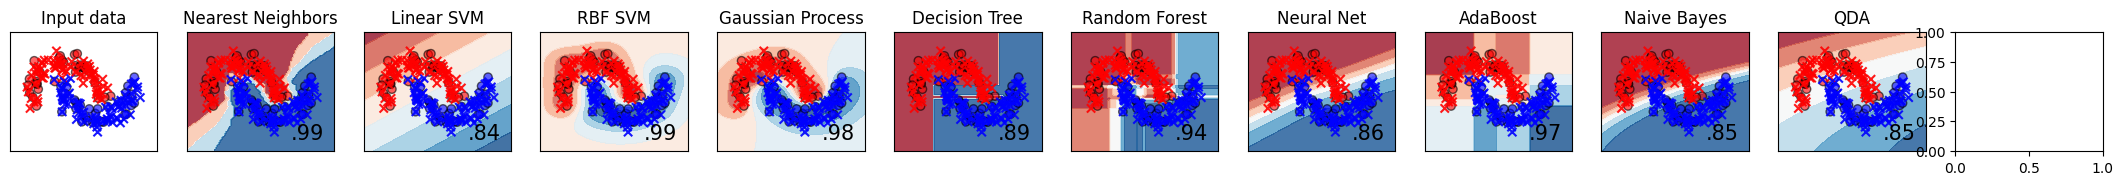

In [3]:
n_samples = 200
datasets = [
    make_moons(n_samples = n_samples, noise=0.15, random_state=1),
    make_circles(n_samples = n_samples, noise=0.15, factor=0.5, random_state=0),
    make_linearly_separable(n_samples= n_samples, n_features=2, n_redundant=0, n_informative=2, random_state=1, n_clusters_per_class=1, noise = .5, randomstate = 10),
    make_blobs(n_samples=n_samples, centers=2, cluster_std=4, random_state=1),
    make_xor(n_samples=n_samples)
]


figure = plt.figure(figsize=(27, 9))
i = 1
for ds_cnt, ds in enumerate(datasets):
    X, y = ds
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.7, random_state=42
    )

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5


    # just plot the dataset first
    cm = plt.cm.RdBu
    cm_bright = ListedColormap(["#FF0000", "#0000FF"])
    ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
    if ds_cnt == 0:
        ax.set_title("Input data")
    # Plot the training points
    ax.scatter(
        X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k", alpha=0.6
        )
    # Plot the testing points
    ax.scatter(
        X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, marker='x', alpha=0.9
    )
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(())
    ax.set_yticks(())
    i += 1

    # iterate over classifiers
    for name, clf in zip(names, classifiers):
        ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
    
        clf = make_pipeline(StandardScaler(), clf)
        clf.fit(X_train, y_train)
        if name == "KLRClassifier":
            clf = clf.named_steps['klrclassifier']
            clf.validate(X_train, y_train)
        score = clf.score(X_test, y_test)
        try:  
            DecisionBoundaryDisplay.from_estimator(
                clf, X, cmap=cm, alpha=0.8, ax=ax, eps=0.5
            )
        except:
            resolution = 100
            x_vals = np.linspace(x_min, x_max, 100)
            y_vals = np.linspace(y_min, y_max, 100)
            xx, yy = np.meshgrid(
                np.linspace(x_min, x_max, resolution),
                np.linspace(y_min, y_max, resolution)
                    )
            grid = np.c_[xx.ravel(), yy.ravel()]
            A, B = np.meshgrid(x_vals, y_vals)
            # clf = KLRClassifier()
            clf.fit(X_train,y_train, ridge = 1e-1)
            # clf.fit(X_train,y_train)
            Z = clf.predict_proba(grid)[:,0].reshape(A.shape)
            plt.contourf(A, B, Z, cmap=cm.reversed(), alpha=0.8)

        # Plot the training points
        ax.scatter(
            X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k", alpha=0.6
        )
        # Plot the testing points
        ax.scatter(
            X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, marker = 'x', alpha=0.9
        )

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xticks(())
        ax.set_yticks(())
        if ds_cnt == 0:
            ax.set_title(name)
        ax.text(
            x_max - 0.3,
            y_min + 0.3,
            ("%.2f" % score).lstrip("0"),
            size=15,
            horizontalalignment="right",
        )
        i += 1

plt.tight_layout(); plt.show()

## Brest Cancer Data

In [5]:

from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X, y = data.data, data.target
print(f"Dataset size: {X.shape[0]} samples, {X.shape[1]} features")
rng = np.random.RandomState(42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
for name, clf in zip(names, classifiers):
    clf = make_pipeline(StandardScaler(), clf)
    if name == "KLRClassifier":
        clf = clf.named_steps['klrclassifier']
        clf.fit(X_train, y_train, kernel_name='sqeuclidean')
        clf.validate(X_train, y_train)
    else:
        clf.fit(X_train, y_train)

    score = clf.score(X_test, y_test)
    print(f"{name} accuracy: {score:.2f}")

Dataset size: 569 samples, 30 features
Nearest Neighbors accuracy: 0.95
Linear SVM accuracy: 0.98
RBF SVM accuracy: 0.62
Gaussian Process accuracy: 0.98
Decision Tree accuracy: 0.95
Random Forest accuracy: 0.95
Neural Net accuracy: 0.98
AdaBoost accuracy: 0.96
Naive Bayes accuracy: 0.96
QDA accuracy: 0.96


/Users/leonardosantoro/Library/Python/3.9/lib/python/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


KLRClassifier accuracy: 0.94


## FLW pairs

In [6]:
from sklearn.datasets import fetch_lfw_pairs
data = fetch_lfw_pairs(subset='train', resize=0.5)
X, y = data.data, data.target
print(f"Dataset size: {X.shape[0]} samples, {X.shape[1]} features")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=0)
for name, clf in zip(names, classifiers):
    clf = make_pipeline(StandardScaler(), clf)
    clf.fit(X_train, y_train)
    score = clf.score(X_test, y_test)
    print(f"{name} accuracy: {score:.2f}")


Dataset size: 2200 samples, 5828 features
Nearest Neighbors accuracy: 0.65
Linear SVM accuracy: 0.55
RBF SVM accuracy: 0.47


/Users/leonardosantoro/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Gaussian Process accuracy: 0.47
Decision Tree accuracy: 0.52
Random Forest accuracy: 0.49
Neural Net accuracy: 0.65
AdaBoost accuracy: 0.56
Naive Bayes accuracy: 0.58


/Users/leonardosantoro/Library/Python/3.9/lib/python/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Users/leonardosantoro/Library/Python/3.9/lib/python/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


QDA accuracy: 0.52
KLRClassifier accuracy: 0.75


# Multilabel classification

## Benchmark

/Users/leonardosantoro/Library/Python/3.9/lib/python/site-packages/sklearn/gaussian_process/_gpc.py:455: RuntimeWarning: overflow encountered in exp
  - np.log1p(np.exp(-(self.y_train_ * 2 - 1) * f)).sum()


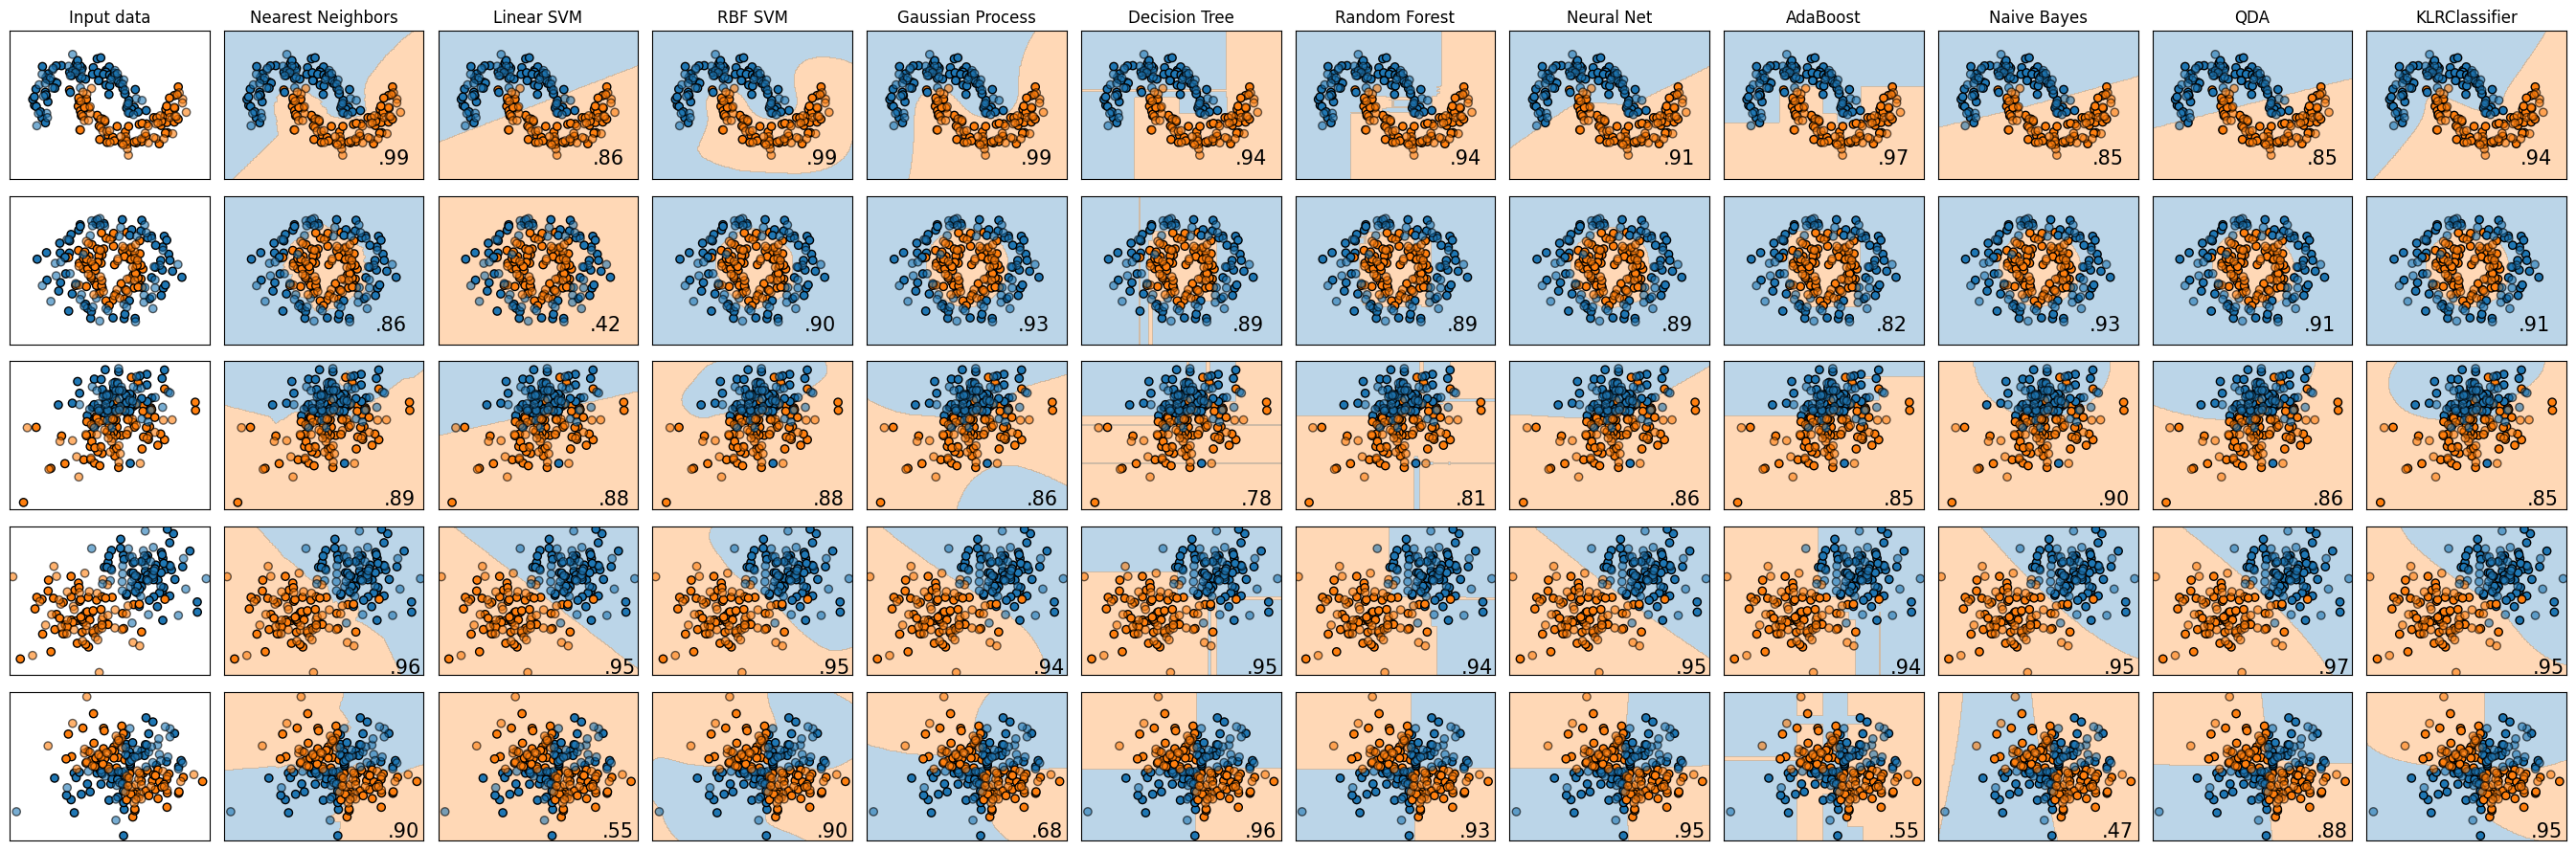

In [7]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

figure = plt.figure(figsize=(27, 9))
i = 1

for ds_cnt, ds in enumerate(datasets):
    X, y = ds
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=42
    )

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # Get class count and colormaps
    unique_classes = np.unique(y)
    n_classes = len(unique_classes)
    cm_bright = ListedColormap(mpl_colormaps['tab10'].colors[:n_classes])

    # Input plot
    ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
    if ds_cnt == 0:
        ax.set_title("Input data")
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k")
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6, edgecolors="k")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(())
    ax.set_yticks(())
    i += 1

    for name, clf in zip(names, classifiers):
        ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
        clf_pipeline = make_pipeline(StandardScaler(), clf)
        clf_pipeline.fit(X_train, y_train)

        score = clf_pipeline.score(X_test, y_test)

        # Manual decision boundary for multiclass
        resolution = 200
        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, resolution),
            np.linspace(y_min, y_max, resolution)
        )
        grid = np.c_[xx.ravel(), yy.ravel()]
        try:
            Z = clf_pipeline.predict(grid)
        except:
            Z = np.zeros(len(grid))

        Z = Z.reshape(xx.shape)
        ax.contourf(xx, yy, Z, cmap=cm_bright, alpha=0.3, levels=np.arange(n_classes + 1) - 0.5)

        # Scatter plot
        ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k")
        ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6, edgecolors="k")
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xticks(())
        ax.set_yticks(())
        if ds_cnt == 0:
            ax.set_title(name)
        ax.text(x_max - 0.3, y_min + 0.3, ("%.2f" % score).lstrip("0"), size=15, horizontalalignment="right")
        i += 1

plt.tight_layout()
plt.show()


## Iris

In [8]:

from sklearn.datasets import load_iris
data = load_iris()
X, y = data.data, data.target
noise = rng.normal(scale=.5, size=X.shape)
X += noise

print(f"Dataset size: {X.shape[0]} samples, {X.shape[1]} features")
rng = np.random.RandomState(42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
for name, clf in zip(names, classifiers):
    clf = make_pipeline(StandardScaler(), clf)
    if name == "KLRClassifier":
        clf = clf.named_steps['klrclassifier']
        clf.fit(X_train, y_train, kernel_name='sqeuclidean')
        clf.validate(X_train, y_train)
    else:
        clf.fit(X_train, y_train)

    score = clf.score(X_test, y_test)
    print(f"{name} accuracy: {score:.2f}")

Dataset size: 150 samples, 4 features
Nearest Neighbors accuracy: 0.87
Linear SVM accuracy: 0.93
RBF SVM accuracy: 0.83
Gaussian Process accuracy: 0.93
Decision Tree accuracy: 0.90
Random Forest accuracy: 0.87
Neural Net accuracy: 0.87
AdaBoost accuracy: 0.83
Naive Bayes accuracy: 0.87
QDA accuracy: 0.90
KLRClassifier accuracy: 0.87


## Digits

In [9]:
from sklearn.datasets import load_digits

digits = load_digits()
X, y = digits.data, digits.target
X += rng.normal(scale=.3, size=X.shape)  # Adding noise to the dataset
print(f"Dataset size: {X.shape[0]} samples, {X.shape[1]} features")

rng = np.random.RandomState(42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
for name, clf in zip(names, classifiers):
    clf = make_pipeline(StandardScaler(), clf)
    if name == "KLRClassifier":
        clf = clf.named_steps['klrclassifier']
        clf.fit(X_train, y_train, kernel_name='euclidean')
        clf.validate(X_train, y_train)
    else:
        clf.fit(X_train, y_train)

    score = clf.score(X_test, y_test)
    print(f"{name} accuracy: {score:.2f}")

Dataset size: 1797 samples, 64 features
Nearest Neighbors accuracy: 0.95
Linear SVM accuracy: 0.96
RBF SVM accuracy: 0.09
Gaussian Process accuracy: 0.09
Decision Tree accuracy: 0.66
Random Forest accuracy: 0.74
Neural Net accuracy: 0.97
AdaBoost accuracy: 0.80
Naive Bayes accuracy: 0.89
QDA accuracy: 0.94
KLRClassifier accuracy: 0.99


## MNIST

#

In [49]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1)
X, y = mnist.data.values, mnist.target.values
print(f"Dataset size: {X.shape[0]} samples, {X.shape[1]} features")
X, y = X[:5000], y[:5000]  # Use a smaller subset for faster training


Dataset size: 70000 samples, 784 features


In [35]:

names = [
    "Nearest Neighbors",
    "Linear SVM",
    "RBF SVM",
    "Decision Tree",
    "Random Forest",
    "Neural Net",
    "AdaBoost",
    "KLRClassifier"
]


classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025, random_state=42),
    SVC(gamma=2, C=1, random_state=42),
    DecisionTreeClassifier(max_depth=5, random_state=42),
    RandomForestClassifier(
        max_depth=5, n_estimators=10, max_features=1, random_state=42
    ),
    MLPClassifier(alpha=1, max_iter=1000, random_state=42),
    AdaBoostClassifier(random_state=42),
    KLRClassifier()
]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)
for name, clf in zip(names, classifiers):
    # clf = make_pipeline(StandardScaler(), clf)
    if name == "KLRClassifier":
        # clf = clf.named_steps['klrclassifier']
        clf.fit(X_train, y_train, kernel_name='euclidean',ridge = 1e-3)
        # clf.validate(X_train, y_train)
    else:
        clf.fit(X_train, y_train)

    score = clf.score(X_test, y_test)
    print(f"{name} accuracy: {score:.2f}")

Nearest Neighbors accuracy: 0.91
Linear SVM accuracy: 0.91
RBF SVM accuracy: 0.11
Decision Tree accuracy: 0.67
Random Forest accuracy: 0.61
Neural Net accuracy: 0.88
AdaBoost accuracy: 0.63


AttributeError: 'KLRClassifier' object has no attribute 'named_steps'

In [52]:
clf.fit(X_train, y_train, kernel_name='euclidean',ridge = 1e-3)
score = clf.score(X_test, y_test)
print(f"{name} accuracy: {score:.2f}")

KLRClassifier accuracy: 0.00


In [43]:
clf.fit(X_train, y_train, kernel_name='euclidean',ridge = 1e1)
score = clf.score(X_test, y_test)
print(f"{name} accuracy: {score:.2f}")
ls = clf.decision_function(X_test)

KLRClassifier accuracy: 0.00


In [48]:
y_test.iloc[0]

'1'

<Axes: >

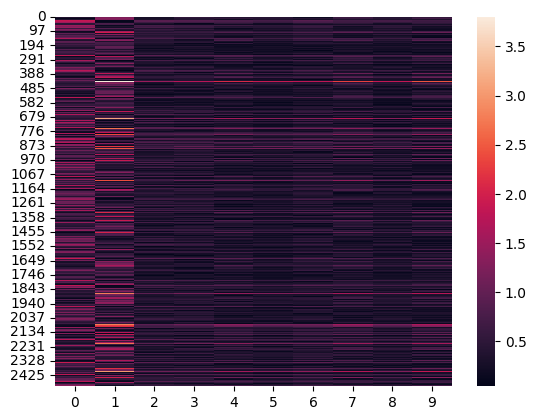

In [44]:
sns.heatmap(ls.T)